# 05 — Evaluate & Compare Models

**Goal:** Evaluate all 7 models on the test set, compare metrics, visualize results.  
**Reads:** `data/processed/test.csv`, `data/processed/ssp_forecast_panel.csv`, all `.pkl` files in `models/`  
**Outputs:**
- `outputs/model_comparison.csv`
- `outputs/model_comparison_r2.png`
- `outputs/actual_vs_predicted.png`
- `outputs/approach_a_vs_b.png`

## Imports and paths

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
OUTPUTS_DIR = Path("../outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ["gdp_per_capita", "hdi", "control_of_corruption", "employment_agriculture", "gini"]
TARGETS = ["poverty_3", "poverty_8_30", "poverty_10"]  # poverty_4_20 excluded (poverty gap data)
PRIMARY_TARGET = "poverty_3"
MODEL_NAMES = ["XGBoost_CPU", "XGBoost_GPU", "LightGBM", "RandomForest", "Ridge", "MLP", "GAM"]
NEEDS_SCALING = {"Ridge", "MLP"}

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)

## Load test data

In [2]:
test = pd.read_csv(DATA_PROCESSED / "test.csv")
print(f"Test set: {test.shape}")
test.head()

Test set: (373, 14)


,country_name,country_code,year,gdp_per_capita,hdi,control_of_corruption,employment_agriculture,gini,gini_observed,poverty_3,poverty_8_30,poverty_10,imputation_pct,target_missing_pct
0,Belgium,BEL,1997,23814.835133,0.869,0.767289,2.656517,26.8,True,0.5,0.981724,1.247959,0.2,0.0
1,Belgium,BEL,2000,27816.741429,0.880,0.789372,1.907901,33.1,True,0.3,0.977943,0.977943,0.0,0.0
2,Belgium,BEL,2003,30893.677872,0.889,0.775023,1.721096,28.1,True,0.4,0.906841,1.094912,0.0,0.0
3,Belgium,BEL,2004,32010.668965,0.893,0.772077,2.218832,30.5,True,0.1,0.421006,0.444925,0.0,0.0
4,Belgium,BEL,2005,33155.647152,0.897,0.775432,2.038964,29.3,True,0.3,0.550234,0.731529,0.0,0.0


## Evaluate all models

Metrics: RMSE, MAE, R² (no MAPE — poverty values near zero cause division issues).

In [3]:
def evaluate(y_true, y_pred):
    """Compute regression metrics."""
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [4]:
results = []

for target in TARGETS:
    # Filter test rows where this target is not NaN
    test_df = test.dropna(subset=[target])
    X_test = test_df[FEATURES].values
    y_test = test_df[target].values
    
    # Load scaler for this target (for Ridge/MLP)
    scaler = joblib.load(MODELS_DIR / f"scaler_{target}.pkl")
    X_test_scaled = scaler.transform(X_test)
    
    for model_name in MODEL_NAMES:
        model_path = MODELS_DIR / f"{model_name}_{target}.pkl"
        if not model_path.exists():
            print(f"  MISSING: {model_path.name}")
            continue
        
        model = joblib.load(model_path)
        
        # Use scaled features for Ridge/MLP
        X = X_test_scaled if model_name in NEEDS_SCALING else X_test
        y_pred = model.predict(X)
        
        metrics = evaluate(y_test, y_pred)
        metrics["Model"] = model_name
        metrics["Threshold"] = target
        results.append(metrics)

results_df = pd.DataFrame(results)[["Model", "Threshold", "RMSE", "MAE", "R2"]]
print(f"Evaluation results: {results_df.shape[0]} rows")
results_df.head(10)

Evaluation results: 21 rows


,Model,Threshold,RMSE,MAE,R2
0,XGBoost_CPU,poverty_3,8.415733,4.821457,0.679468
1,XGBoost_GPU,poverty_3,8.415733,4.821457,0.679468
2,LightGBM,poverty_3,8.917662,4.901521,0.640094
3,RandomForest,poverty_3,7.946345,4.429892,0.714226
4,Ridge,poverty_3,8.522609,5.748449,0.671275
5,MLP,poverty_3,7.508107,4.029966,0.744878
6,GAM,poverty_3,7.988145,4.881030,0.711212
7,XGBoost_CPU,poverty_8_30,12.593155,7.713111,0.829298
8,XGBoost_GPU,poverty_8_30,12.593155,7.713111,0.829298
9,LightGBM,poverty_8_30,12.467997,7.712696,0.832674


### Full results table

In [5]:
# Show results for primary target
primary_results = results_df[results_df["Threshold"] == PRIMARY_TARGET].sort_values("R2", ascending=False)
print(f"=== Results for {PRIMARY_TARGET} ===")
print(primary_results.to_string(index=False))

best_model_name = primary_results.iloc[0]["Model"]
print(f"\nBest model: {best_model_name} (R² = {primary_results.iloc[0]['R2']:.4f})")

=== Results for poverty_3 ===
       Model Threshold     RMSE      MAE       R2
         MLP poverty_3 7.508107 4.029966 0.744878
RandomForest poverty_3 7.946345 4.429892 0.714226
         GAM poverty_3 7.988145 4.881030 0.711212
 XGBoost_CPU poverty_3 8.415733 4.821457 0.679468
 XGBoost_GPU poverty_3 8.415733 4.821457 0.679468
       Ridge poverty_3 8.522609 5.748449 0.671275
    LightGBM poverty_3 8.917662 4.901521 0.640094

Best model: MLP (R² = 0.7449)


In [6]:
# Save full comparison table
results_df.to_csv(OUTPUTS_DIR / "model_comparison.csv", index=False)
print(f"Saved: outputs/model_comparison.csv")

Saved: outputs/model_comparison.csv


## Bar chart: R² comparison for primary target

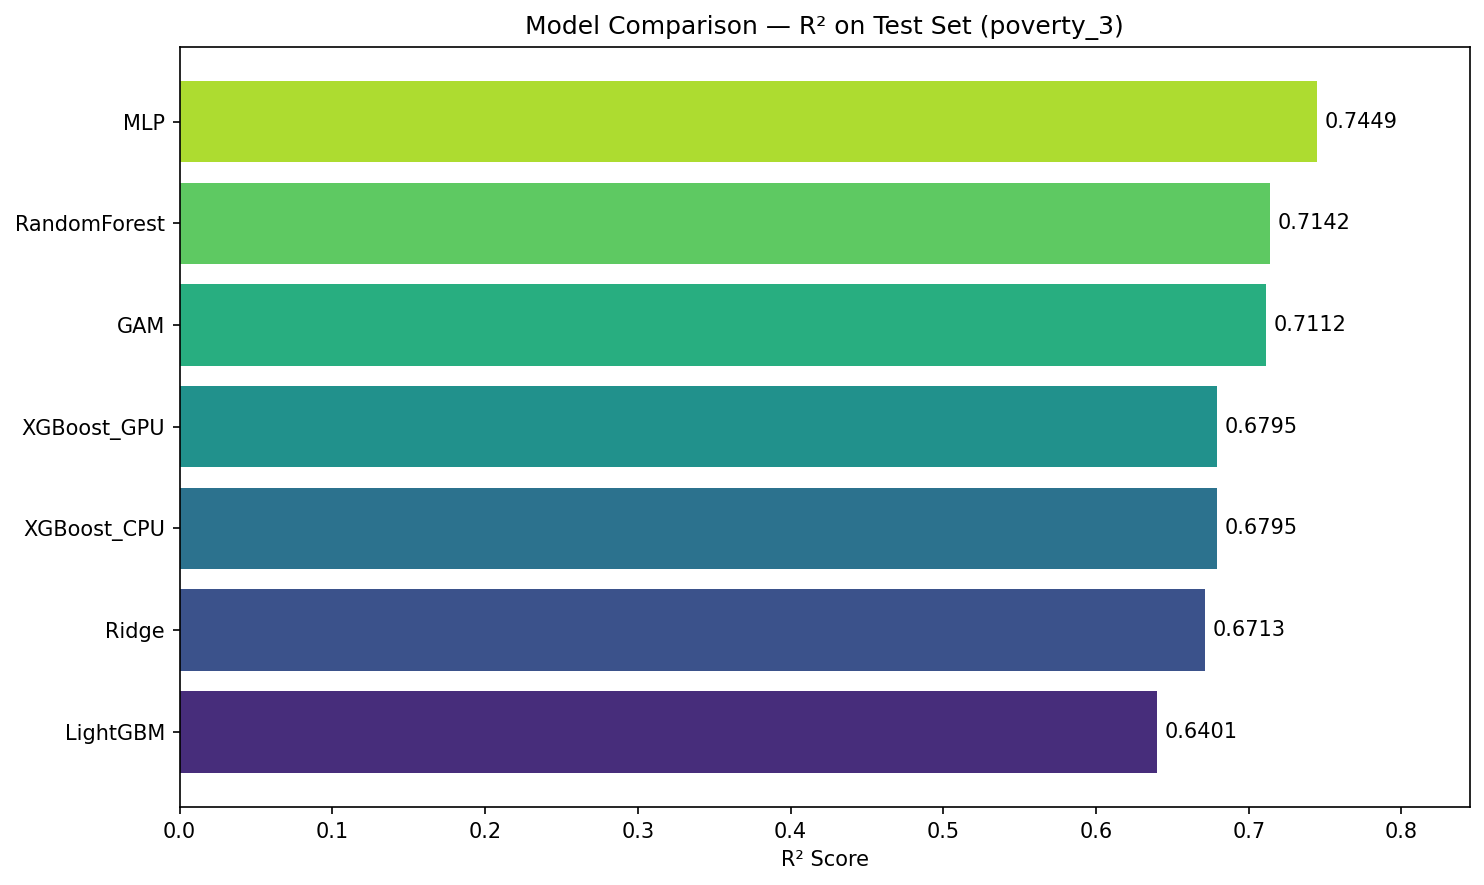

Saved: outputs/model_comparison_r2.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = primary_results.sort_values("R2", ascending=True)
colors = sns.color_palette("viridis", len(plot_data))

bars = ax.barh(plot_data["Model"], plot_data["R2"], color=colors)

# Add value labels on bars
for bar, val in zip(bars, plot_data["R2"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=10)

ax.set_xlabel("R² Score")
ax.set_title(f"Model Comparison — R² on Test Set ({PRIMARY_TARGET})")
ax.set_xlim(0, min(1.05, plot_data["R2"].max() + 0.1))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "model_comparison_r2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/model_comparison_r2.png")

## Scatter plot: Actual vs Predicted (best model)

In [8]:
# Load the best model and generate predictions
test_primary = test.dropna(subset=[PRIMARY_TARGET])
X_test_primary = test_primary[FEATURES].values
y_test_primary = test_primary[PRIMARY_TARGET].values

best_model = joblib.load(MODELS_DIR / f"{best_model_name}_{PRIMARY_TARGET}.pkl")

# Scale if needed
if best_model_name in NEEDS_SCALING:
    scaler = joblib.load(MODELS_DIR / f"scaler_{PRIMARY_TARGET}.pkl")
    X_pred = scaler.transform(X_test_primary)
else:
    X_pred = X_test_primary

y_pred_best = best_model.predict(X_pred)

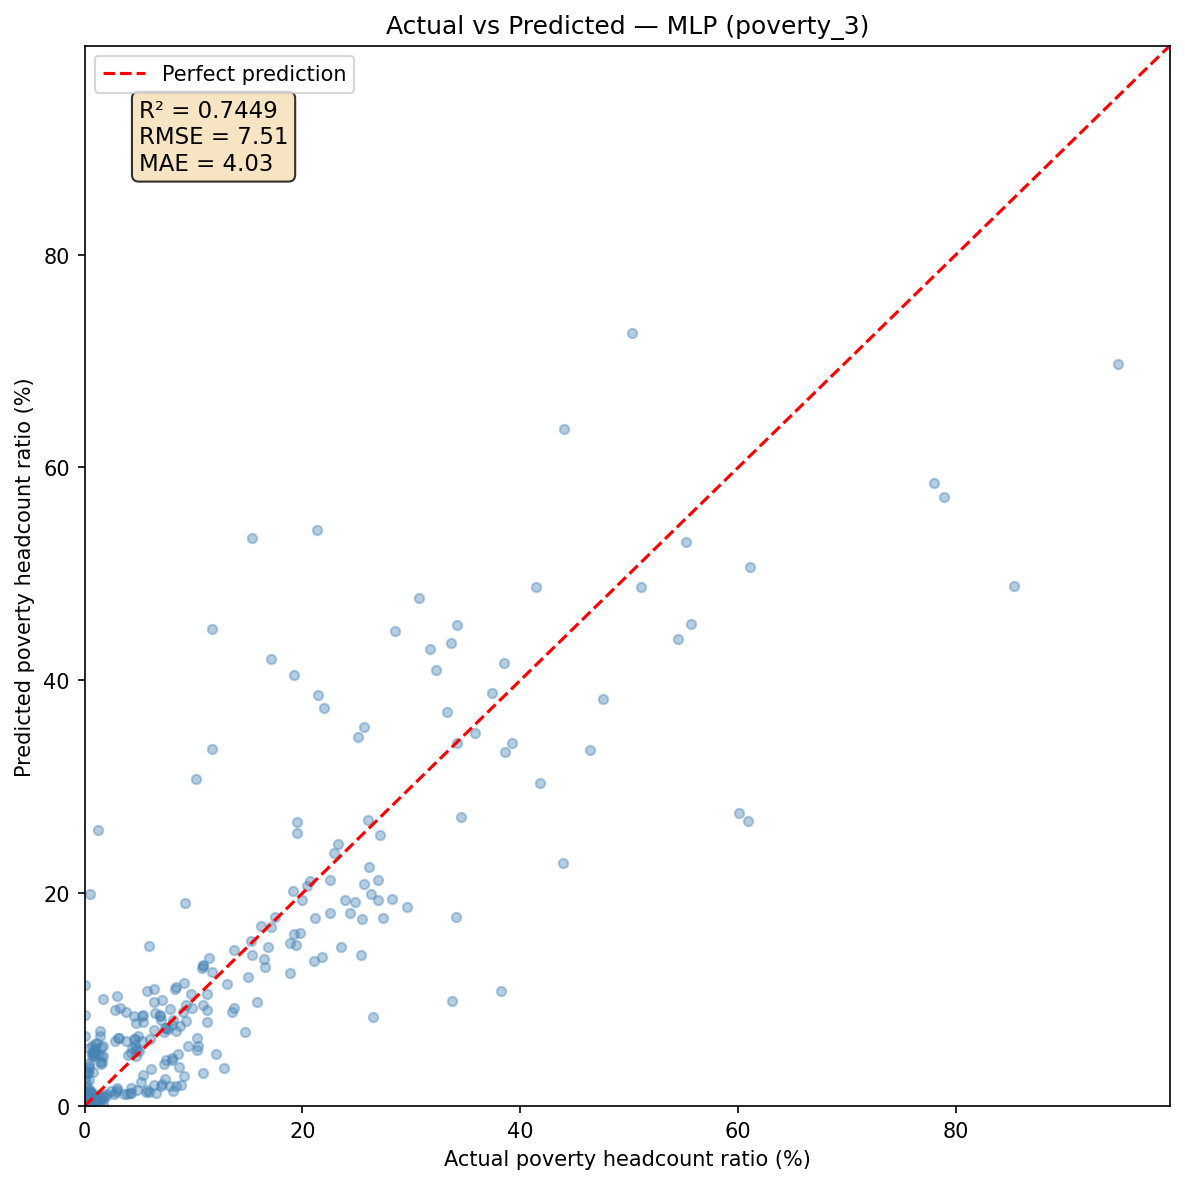

Saved: outputs/actual_vs_predicted.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test_primary, y_pred_best, alpha=0.4, s=20, color="steelblue")

# Perfect prediction line
lims = [0, max(y_test_primary.max(), y_pred_best.max()) * 1.05]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")

ax.set_xlabel("Actual poverty headcount ratio (%)")
ax.set_ylabel("Predicted poverty headcount ratio (%)")
ax.set_title(f"Actual vs Predicted — {best_model_name} ({PRIMARY_TARGET})")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

# Add metrics text
metrics = evaluate(y_test_primary, y_pred_best)
text = f"R² = {metrics['R2']:.4f}\nRMSE = {metrics['RMSE']:.2f}\nMAE = {metrics['MAE']:.2f}"
ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=11,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/actual_vs_predicted.png")

## Approach A vs B: 2050 vs 2100 predictions

- **Approach A:** Predictions up to 2050 (all SSP features are real projections)
- **Approach B:** Predictions up to 2100 (some features extrapolated beyond source data)

Both use the same model trained on historical data.  
We compare trajectories for a few example countries to show where they diverge.

In [10]:
# Load SSP forecast panel
forecast = pd.read_csv(DATA_PROCESSED / "ssp_forecast_panel.csv")
print(f"Forecast panel: {forecast.shape}")
print(f"Years: {sorted(forecast['year'].unique())}")
print(f"Scenarios: {forecast['scenario'].unique()}")

Forecast panel: (9045, 11)
Years: [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2065, 2070, 2075, 2080, 2085, 2090, 2095]
Scenarios: ['SSP1' 'SSP4' 'SSP5']


In [11]:
# Use the best model to predict poverty on the forecast data
# We use SSP1 as the reference scenario for this comparison
scenario_for_comparison = "SSP1"

fc = forecast[forecast["scenario"] == scenario_for_comparison].copy()

# Drop rows missing any feature
fc_valid = fc.dropna(subset=FEATURES)
print(f"Valid forecast rows ({scenario_for_comparison}): {len(fc_valid)}")

X_fc = fc_valid[FEATURES].values

# Scale if needed
if best_model_name in NEEDS_SCALING:
    scaler = joblib.load(MODELS_DIR / f"scaler_{PRIMARY_TARGET}.pkl")
    X_fc = scaler.transform(X_fc)

fc_valid["predicted_poverty"] = best_model.predict(X_fc)

# Mark approach
fc_valid["approach"] = fc_valid["year"].apply(lambda y: "A (≤2050)" if y <= 2050 else "B (2055–2100)")

print(f"Approach A rows: {(fc_valid['year'] <= 2050).sum()}")
print(f"Approach B rows: {(fc_valid['year'] > 2050).sum()}")

Valid forecast rows (SSP1): 2250
Approach A rows: 900
Approach B rows: 1350


### Plot: Approach A vs B for example countries

In [12]:
# Pick example countries: a mix of rich, middle-income, and poor
example_countries = ["India", "Nigeria", "Brazil", "China", "Ethiopia"]

# Check which ones are available
available = fc_valid["country_name"].unique()
example_countries = [c for c in example_countries if c in available]
print(f"Example countries: {example_countries}")

# If some are missing, fill with the most-populated available countries
if len(example_countries) < 4:
    extras = [c for c in available if c not in example_countries][:5 - len(example_countries)]
    example_countries.extend(extras)
    print(f"Adjusted example countries: {example_countries}")

Example countries: ['India', 'Nigeria', 'Brazil', 'China', 'Ethiopia']


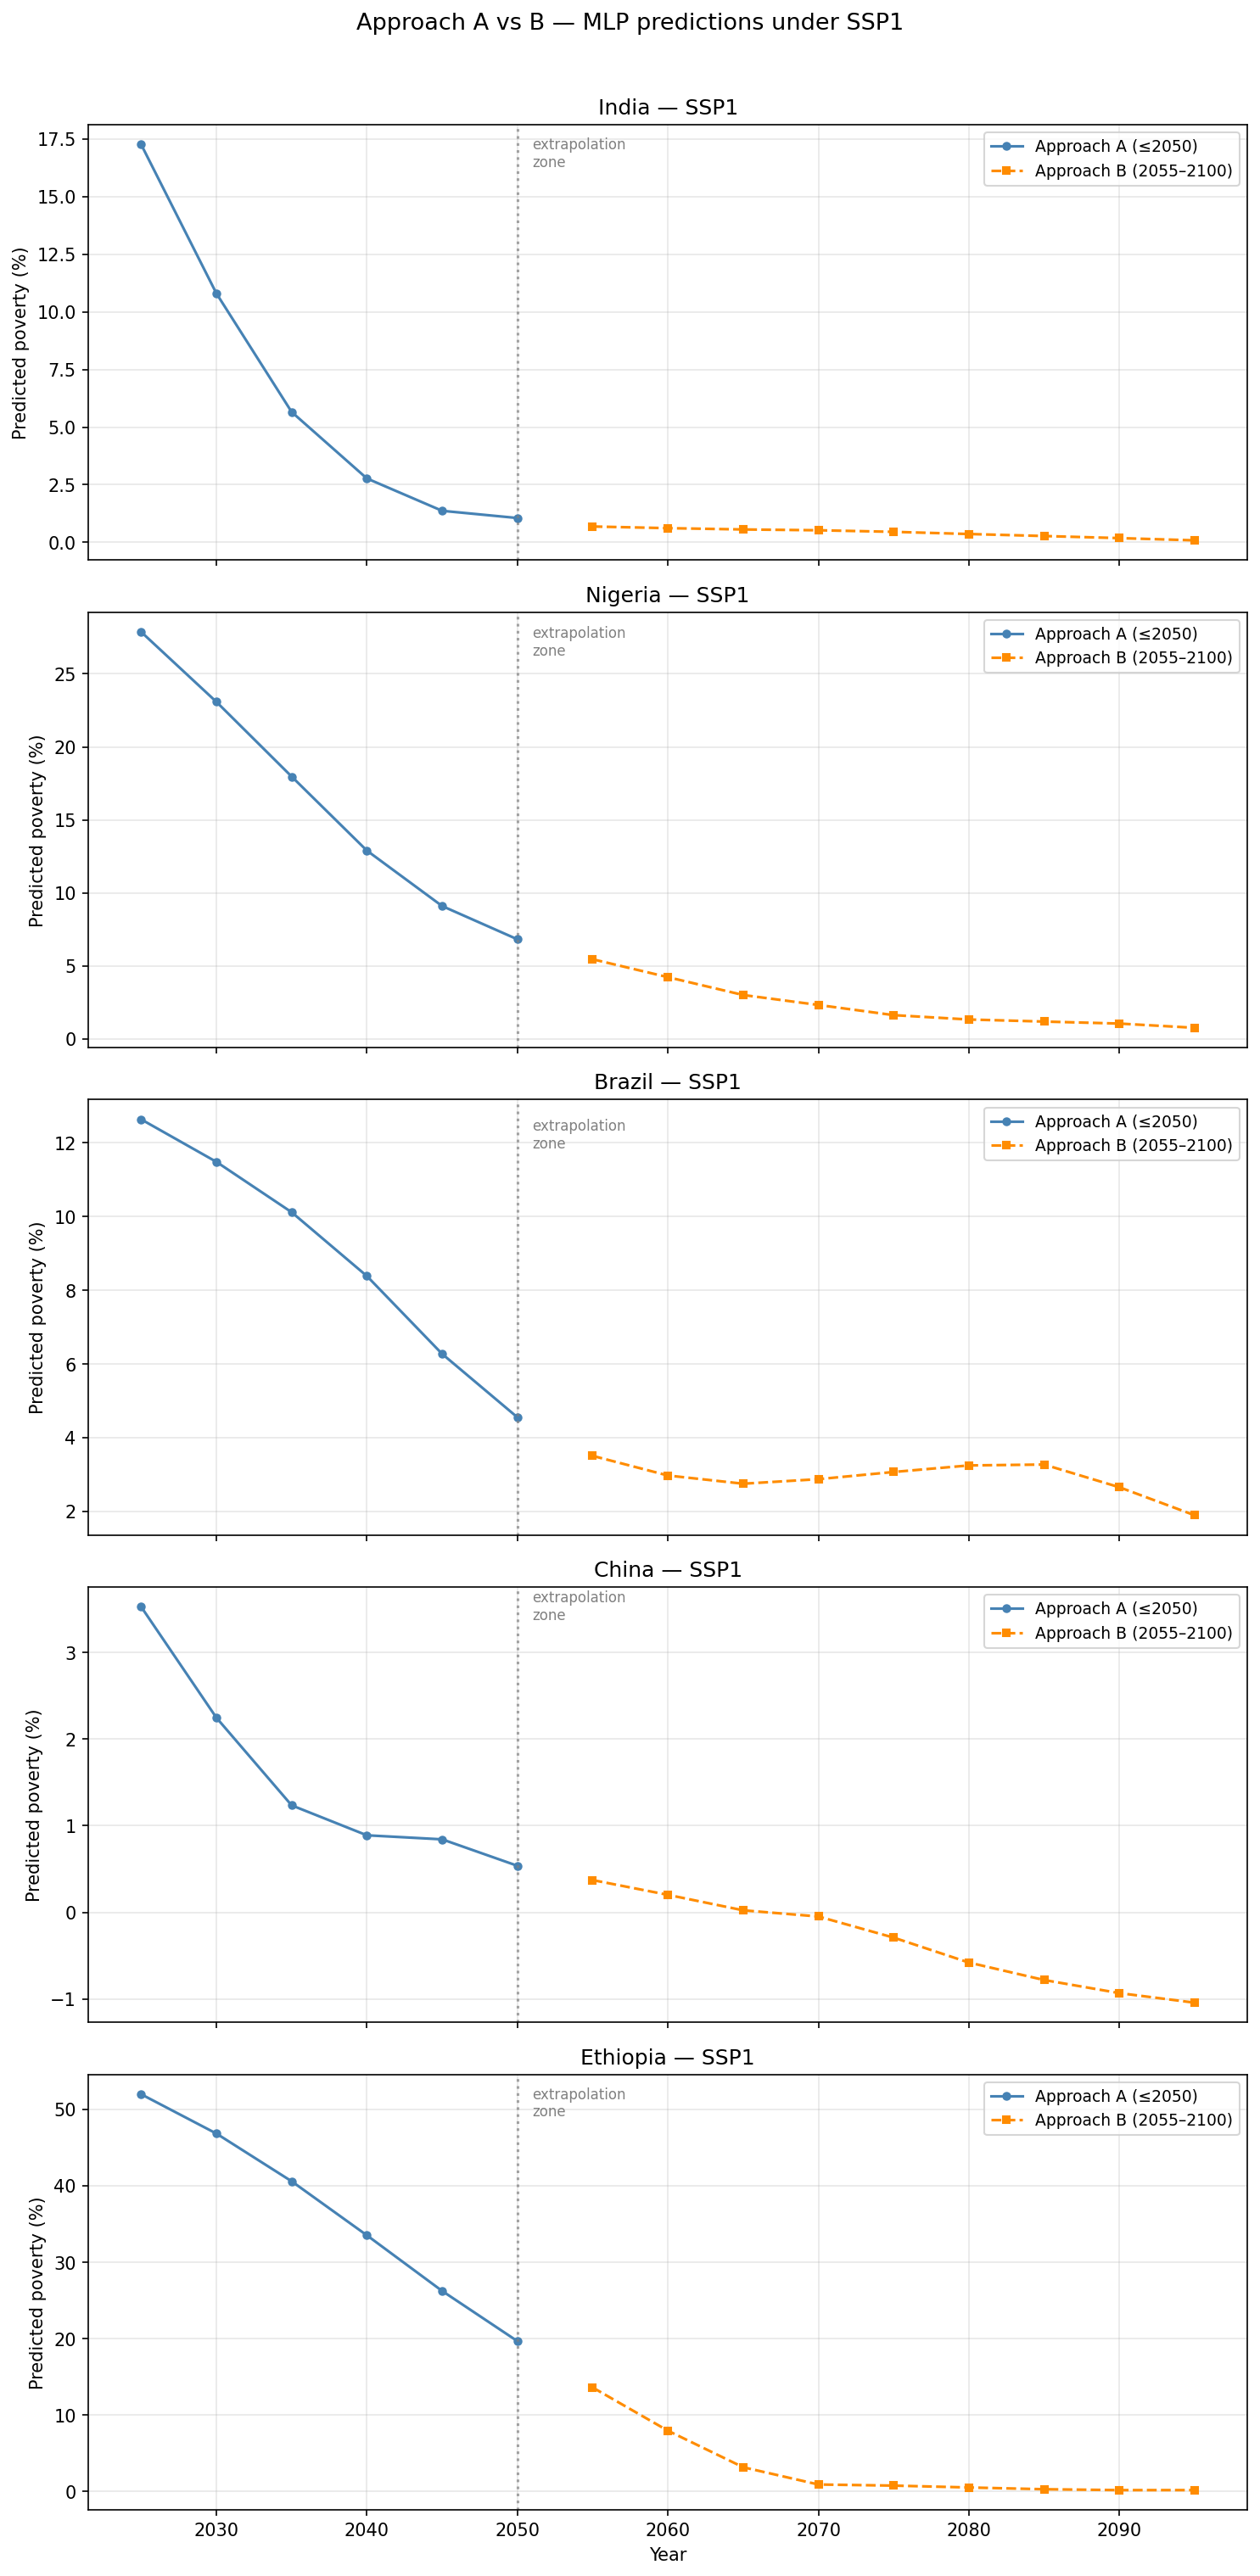

Saved: outputs/approach_a_vs_b.png


In [13]:
fig, axes = plt.subplots(len(example_countries), 1, figsize=(10, 4 * len(example_countries)),
                          sharex=True)

if len(example_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, example_countries):
    df_c = fc_valid[fc_valid["country_name"] == country].sort_values("year")
    
    # Approach A: up to 2050
    df_a = df_c[df_c["year"] <= 2050]
    # Approach B: full range (includes 2050 for continuity)
    df_b = df_c
    
    ax.plot(df_a["year"], df_a["predicted_poverty"], "o-", color="steelblue",
            label="Approach A (≤2050)", markersize=4)
    ax.plot(df_b[df_b["year"] > 2050]["year"],
            df_b[df_b["year"] > 2050]["predicted_poverty"],
            "s--", color="darkorange", label="Approach B (2055–2100)", markersize=4)
    
    # Vertical line at 2050
    ax.axvline(x=2050, color="gray", linestyle=":", alpha=0.7)
    ax.text(2051, ax.get_ylim()[1] * 0.9, "extrapolation\nzone", fontsize=8, color="gray")
    
    ax.set_ylabel("Predicted poverty (%)")
    ax.set_title(f"{country} — {scenario_for_comparison}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Year")
fig.suptitle(f"Approach A vs B — {best_model_name} predictions under {scenario_for_comparison}",
             fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "approach_a_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/approach_a_vs_b.png")

## Results for all thresholds

In [14]:
# Pivot table: R² for each model × threshold
r2_pivot = results_df.pivot(index="Model", columns="Threshold", values="R2")
r2_pivot["mean_R2"] = r2_pivot.mean(axis=1)
r2_pivot = r2_pivot.sort_values("mean_R2", ascending=False)

print("R² scores across all thresholds:")
print(r2_pivot.round(4).to_string())

R² scores across all thresholds:
Threshold     poverty_10  poverty_3  poverty_8_30  mean_R2
Model                                                     
MLP               0.9038     0.7449        0.8616   0.8368
RandomForest      0.9079     0.7142        0.8746   0.8322
GAM               0.9016     0.7112        0.8832   0.8320
Ridge             0.8688     0.6713        0.8613   0.8004
XGBoost_CPU       0.8640     0.6795        0.8293   0.7909
XGBoost_GPU       0.8640     0.6795        0.8293   0.7909
LightGBM          0.8647     0.6401        0.8327   0.7791


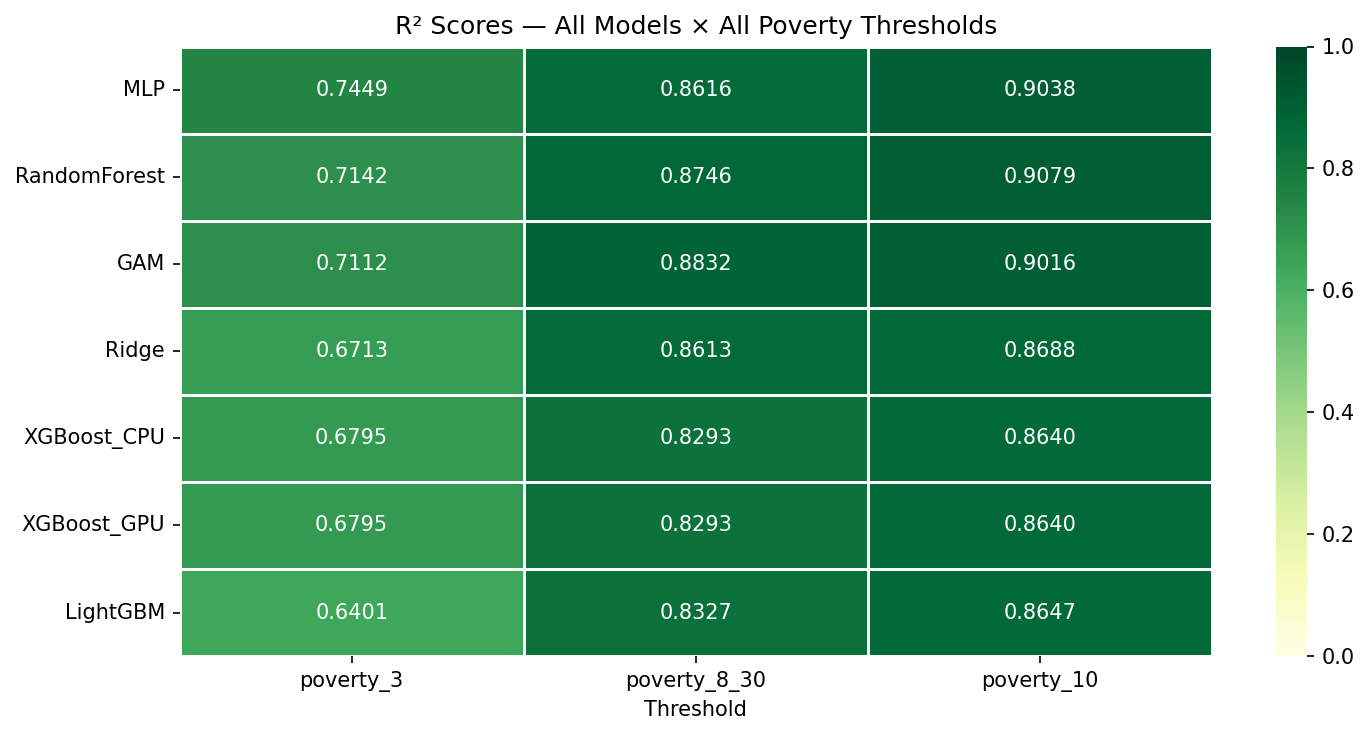

Saved: outputs/r2_heatmap_all.png


In [15]:
# Heatmap of R² scores
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    r2_pivot[TARGETS].round(4),
    annot=True, fmt=".4f", cmap="YlGn", ax=ax,
    vmin=0, vmax=1, linewidths=0.5
)
ax.set_title("R² Scores — All Models × All Poverty Thresholds")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "r2_heatmap_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/r2_heatmap_all.png")

---
**Outputs produced:**
- `outputs/model_comparison.csv` — RMSE, MAE, R² for all 7 models × 4 thresholds
- `outputs/model_comparison_r2.png` — bar chart of R² for primary target
- `outputs/actual_vs_predicted.png` — scatter plot for best model
- `outputs/approach_a_vs_b.png` — Approach A (≤2050) vs B (full 2100) trajectories
- `outputs/r2_heatmap_all.png` — heatmap of R² across all models and thresholds

Next: notebook 06 runs SHAP analysis on the best model.